# What Makes a Fashion Review Helpful on Amazon?

**Dataset:** McAuley Lab Amazon Reviews 2023 (Amazon Fashion category)  
**Tools:** PySpark, MLlib, Matplotlib, Seaborn  
**Research question:** What distinguishes reviews that other shoppers mark as "helpful" from those they ignore?

This notebook covers:
1. Data loading and cleaning
2. Rating distribution by verified purchase status (GroupBy, Spark SQL)
3. Helpfulness by price tier (Join + Window ntile)
4. Temporal review trends (Window lag, CTE, running average)
5. Review text length vs. helpfulness (feature engineering)
6. TF-IDF keyword analysis (MLlib Pipeline)
7. Helpfulness prediction model (Logistic Regression)
8. Retail analytics deep dives (helpfulness by rating, photo reviews, satisfaction trend)
9. Key findings and retail-actionable insights

## 0. Setup

In [1]:
import sys
sys.path.insert(0, "..")

from src.config import FIGURES_DIR, USE_SAMPLE
from src.spark_session import get_spark_session
from src.data_loader import (
    download_reviews, download_metadata,
    load_reviews_spark, load_metadata_spark,
)
from src.preprocessing import (
    clean_reviews, parse_timestamp, add_text_length,
    add_text_length_bin, add_word_count,
    parse_price, join_reviews_metadata, add_price_quartile,
)
from src.analysis import (
    rating_by_verified, rating_by_verified_sql,
    helpfulness_by_price_tier, temporal_trends_sql,
    helpfulness_by_text_length,
)
from src.text_pipeline import (
    build_tfidf_pipeline, build_classification_pipeline,
    prepare_for_classification, train_test_split,
    extract_top_tfidf_terms,
)
from src.evaluation import evaluate_binary_classification, get_confusion_counts
from src.visualization import (
    plot_rating_distribution, plot_helpfulness_by_price,
    plot_temporal_trends, plot_helpfulness_by_text_length,
    plot_model_roc_data,
)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print(f"Sample mode: {USE_SAMPLE}")

Sample mode: True


## 1. Data Loading and Cleaning

In [2]:
# Download data (only runs if files don't exist yet)
from src.config import REVIEWS_PARQUET, METADATA_PARQUET

if not REVIEWS_PARQUET.exists():
    print("Downloading reviews...")
    download_reviews()
if not METADATA_PARQUET.exists():
    print("Downloading metadata...")
    download_metadata()

print("Data files ready.")

Generating full split: 0 examples [00:00, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/100 [00:00<?, ?ba/s]

Generating full split: 0 examples [00:00, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/827 [00:00<?, ?ba/s]

Data files ready.


In [18]:
spark = get_spark_session()

# Load raw data
reviews_raw = load_reviews_spark(spark)
metadata_raw = load_metadata_spark(spark)

print(f"Raw reviews: {reviews_raw.count():,} rows")
print(f"Raw metadata: {metadata_raw.count():,} rows")
reviews_raw.printSchema()

Raw reviews: 100,000 rows
Raw metadata: 826,108 rows
root
 |-- rating: double (nullable = true)
 |-- title: string (nullable = true)
 |-- text: string (nullable = true)
 |-- images: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- attachment_type: string (nullable = true)
 |    |    |-- large_image_url: string (nullable = true)
 |    |    |-- medium_image_url: string (nullable = true)
 |    |    |-- small_image_url: string (nullable = true)
 |-- asin: string (nullable = true)
 |-- parent_asin: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- helpful_vote: long (nullable = true)
 |-- verified_purchase: boolean (nullable = true)



In [19]:
# Clean and engineer features
reviews = clean_reviews(reviews_raw)
reviews = parse_timestamp(reviews)
reviews = add_text_length(reviews)
reviews = add_text_length_bin(reviews)
reviews = add_word_count(reviews)

reviews.cache()
print(f"Clean reviews: {reviews.count():,} rows")
reviews.show(5, truncate=60)

Clean reviews: 100,000 rows
+------+-----------------+------------------------------------------------------------+------------------------------------------------------------+----------+-----------+----------------------------+-------------+------------+-----------------+----------+-----------+-----------+------------+-----------+---------------+----------+
|rating|            title|                                                        text|                                                      images|      asin|parent_asin|                     user_id|    timestamp|helpful_vote|verified_purchase|is_helpful|review_date|review_year|review_month|text_length|text_length_bin|word_count|
+------+-----------------+------------------------------------------------------------+------------------------------------------------------------+----------+-----------+----------------------------+-------------+------------+-----------------+----------+-----------+-----------+------------+-----------+-

In [20]:
# Prepare metadata and join
metadata = parse_price(metadata_raw)
reviews_with_meta = join_reviews_metadata(reviews, metadata)
reviews_with_price = add_price_quartile(reviews_with_meta)

print(f"Reviews with metadata: {reviews_with_meta.count():,} rows")
print(f"Reviews with valid price: {reviews_with_price.count():,} rows")

Reviews with metadata: 100,000 rows


[Stage 39:>                                                       (0 + 16) / 16]

Reviews with valid price: 17,360 rows


## 2. Rating Distribution by Verified Purchase Status

**PySpark features:** `groupBy`, `agg`, Spark SQL (`GROUP BY`, `CASE WHEN`)

In [6]:
# DataFrame API
rating_dist = rating_by_verified(reviews)
rating_dist.show()

# Spark SQL with CASE WHEN
rating_dist_sql = rating_by_verified_sql(spark, reviews)
rating_dist_sql.show()

fig = plot_rating_distribution(rating_dist_sql)

+-----------------+------+------------+
|verified_purchase|rating|review_count|
+-----------------+------+------------+
|            false|   1.0|         752|
|            false|   2.0|         409|
|            false|   3.0|         673|
|            false|   4.0|        1143|
|            false|   5.0|        3536|
|             true|   1.0|       11264|
|             true|   2.0|        6627|
|             true|   3.0|        9158|
|             true|   4.0|       13037|
|             true|   5.0|       53401|
+-----------------+------+------------+

+-------------+------+------------+
|purchase_type|rating|review_count|
+-------------+------+------------+
|   Unverified|   1.0|         752|
|   Unverified|   2.0|         409|
|   Unverified|   3.0|         673|
|   Unverified|   4.0|        1143|
|   Unverified|   5.0|        3536|
|     Verified|   1.0|       11264|
|     Verified|   2.0|        6627|
|     Verified|   3.0|        9158|
|     Verified|   4.0|       13037|
|     V

## 3. Helpfulness by Price Tier

**PySpark features:** Join (reviews + metadata on `parent_asin`), Window function (`ntile` for price quartiles)

In [7]:
price_analysis = helpfulness_by_price_tier(reviews_with_price)
price_analysis.show()

fig = plot_helpfulness_by_price(price_analysis)

26/02/18 15:15:09 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/02/18 15:15:09 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/02/18 15:15:09 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/02/18 15:15:09 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/02/18 15:15:09 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/02/18 15:15:09 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/02/18 1

+--------------+-------------------+------------------+------------+
|price_quartile|       helpful_rate| avg_helpful_votes|review_count|
+--------------+-------------------+------------------+------------+
|             1| 0.1912442396313364|0.5108294930875577|        4340|
|             2|0.18433179723502305|0.4543778801843318|        4340|
|             3| 0.1859447004608295|0.7052995391705069|        4340|
|             4| 0.2456221198156682|0.7649769585253456|        4340|
+--------------+-------------------+------------------+------------+



26/02/18 15:15:11 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/02/18 15:15:11 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
                                                                                

## 4. Temporal Review Trends

**PySpark features:** Spark SQL CTE, Window functions (`LAG`, running average), date functions

In [8]:
trends = temporal_trends_sql(spark, reviews)
trends.show(20, truncate=False)

fig = plot_temporal_trends(trends)

26/02/18 15:15:22 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/02/18 15:15:22 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/02/18 15:15:22 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/02/18 15:15:22 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/02/18 15:15:22 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/02/18 15:15:22 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/02/18 1

+----------+-------------+--------------------+----------------+------------------+
|year_month|monthly_count|monthly_helpful_rate|prev_month_count|rolling_3mo_avg   |
+----------+-------------+--------------------+----------------+------------------+
|2003-06   |1            |1.0                 |NULL            |1.0               |
|2004-05   |1            |1.0                 |1               |1.0               |
|2005-08   |2            |0.5                 |1               |1.3333333333333333|
|2006-02   |3            |1.0                 |2               |2.0               |
|2006-07   |1            |1.0                 |3               |2.0               |
|2006-10   |1            |1.0                 |1               |1.6666666666666667|
|2006-12   |2            |0.5                 |1               |1.3333333333333333|
|2007-01   |4            |0.25                |2               |2.3333333333333335|
|2007-02   |2            |1.0                 |4               |2.6666666666

26/02/18 15:15:23 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/02/18 15:15:23 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/02/18 15:15:23 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/02/18 15:15:23 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/02/18 15:15:23 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/02/18 15:15:23 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/02/18 1

## 5. Review Text Length vs. Helpfulness

**PySpark features:** `withColumn`, `when`/`otherwise` binning, feature engineering

In [9]:
text_analysis = helpfulness_by_text_length(reviews)
text_analysis.show()

fig = plot_helpfulness_by_text_length(text_analysis)

+---------------+-------------------+------------------+------------------+------------+
|text_length_bin|       helpful_rate| avg_helpful_votes|   avg_text_length|review_count|
+---------------+-------------------+------------------+------------------+------------+
|     very_short|0.09834792870008074|0.1656418855971679|25.348673995404013|       32202|
|          short| 0.1687995938977798|0.3743354083731866| 92.06193058858105|       37429|
|         medium| 0.2732491983035068|0.7737664218475225| 209.5204303299886|       19334|
|           long| 0.3926850014176354|1.3972214346470089|378.92699177771476|        7054|
|      very_long|0.49540159411404044|2.4895769466584916| 660.2976701410178|        3262|
| extremely_long| 0.5730180806675939|5.3630041724617525|1414.2656467315717|         719|
+---------------+-------------------+------------------+------------------+------------+



## 6. TF-IDF Keyword Analysis

**PySpark features:** MLlib Pipeline (Tokenizer, StopWordsRemover, CountVectorizer, IDF)

In [10]:
# Fit TF-IDF on all reviews
tfidf_pipeline = build_tfidf_pipeline()
tfidf_model = tfidf_pipeline.fit(reviews)

# Top distinctive terms by IDF weight
top_terms = extract_top_tfidf_terms(tfidf_model, n=30)
print("Top 30 most distinctive terms (highest IDF):")
for i, term in enumerate(top_terms["top_idf_terms"], 1):
    print(f"  {i}. {term}")

Top 30 most distinctive terms (highest IDF):
  1. />*
  2. winder
  3. pom
  4. cubes
  5. hose
  6. lavender
  7. lacing
  8. circumference
  9. pen
  10. digital
  11. –
  12. usb
  13. film
  14. bezel
  15. exterior
  16. jumper
  17. elephant
  18. heal
  19. cable
  20. puff
  21. :
  22. feather
  23. titanium
  24. shawl
  25. bone
  26. stickers
  27. rust
  28. card,
  29. suspenders
  30. merino


In [11]:
# Compare TF-IDF between helpful and unhelpful reviews
from pyspark.sql import functions as F

helpful_reviews = reviews.filter(F.col("is_helpful") == 1)
unhelpful_reviews = reviews.filter(F.col("is_helpful") == 0)

tfidf_helpful = tfidf_pipeline.fit(helpful_reviews)
tfidf_unhelpful = tfidf_pipeline.fit(unhelpful_reviews)

top_helpful = extract_top_tfidf_terms(tfidf_helpful, n=20)
top_unhelpful = extract_top_tfidf_terms(tfidf_unhelpful, n=20)

print("Top terms in HELPFUL reviews:")
for t in top_helpful["top_idf_terms"][:10]:
    print(f"  - {t}")

print("\nTop terms in UNHELPFUL reviews:")
for t in top_unhelpful["top_idf_terms"][:10]:
    print(f"  - {t}")

Top terms in HELPFUL reviews:
  - *
  - tide
  - rolex
  - invicta
  - film
  - winder
  - absorbent
  - boutik
  - chokers
  - burlap

Top terms in UNHELPFUL reviews:
  - pantsi
  - />-
  - tights,
  - lavender
  - blaze
  - cufflinks
  - fob
  - keeper
  - usb
  - earing


## 7. Helpfulness Prediction Model

**PySpark features:** MLlib (VectorAssembler, LogisticRegression, BinaryClassificationEvaluator), `randomSplit`

In [12]:
# Prepare data for classification
model_df = prepare_for_classification(reviews)
train_df, test_df = train_test_split(model_df)

print(f"Training set: {train_df.count():,} rows")
print(f"Test set: {test_df.count():,} rows")

# Train logistic regression with TF-IDF features
clf_pipeline = build_classification_pipeline()
clf_model = clf_pipeline.fit(train_df)

# Predict on test set
predictions = clf_model.transform(test_df)
predictions.select("text", "is_helpful", "prediction", "probability").show(10, truncate=50)

Training set: 80,167 rows
Test set: 19,817 rows


+--------------------------------------------------+----------+----------+----------------------------------------+
|                                              text|is_helpful|prediction|                             probability|
+--------------------------------------------------+----------+----------+----------------------------------------+
|Sometimes I think this whole Amazon / prime and...|       1.0|       0.0|[0.9590968585662595,0.04090314143374052]|
|My son was so excited about these shoes but the...|       0.0|       0.0|[0.8531796491147902,0.14682035088520984]|
|The color was not what is shown 😏 I received a...|       0.0|       0.0| [0.8429041545468181,0.1570958454531819]|
|I wish I could give zero stars!!! A big ass zer...|       0.0|       0.0|[0.6751591083692052,0.32484089163079477]|
|                                    extremely tiny|       0.0|       0.0| [0.878600356476473,0.12139964352352695]|
|used it for 2 months i loved it and its stooped...|       0.0|       0.0

In [13]:
# Evaluate
metrics = evaluate_binary_classification(predictions)
confusion = get_confusion_counts(predictions)

print("Classification Metrics:")
for k, v in metrics.items():
    print(f"  {k}: {v:.4f}")

print(f"\nConfusion Matrix:")
print(f"  TP={confusion['tp']}, FP={confusion['fp']}")
print(f"  FN={confusion['fn']}, TN={confusion['tn']}")

# Save metrics
import json
from src.config import RESULTS_DIR
(RESULTS_DIR / "metrics").mkdir(parents=True, exist_ok=True)
with open(RESULTS_DIR / "metrics" / "classification_metrics.json", "w") as f:
    json.dump({**metrics, **confusion}, f, indent=2)
print("\nMetrics saved to results/metrics/classification_metrics.json")

Classification Metrics:
  auc_roc: 0.6260
  auc_pr: 0.3150
  accuracy: 0.7924
  weighted_precision: 0.7396
  weighted_recall: 0.7924
  f1: 0.7464

Confusion Matrix:
  TP=531, FP=707
  FN=3407, TN=15172

Metrics saved to results/metrics/classification_metrics.json


## 8. Retail Analytics Deep Dives

Plots a fashion retailer's analytics team would actually want to see.

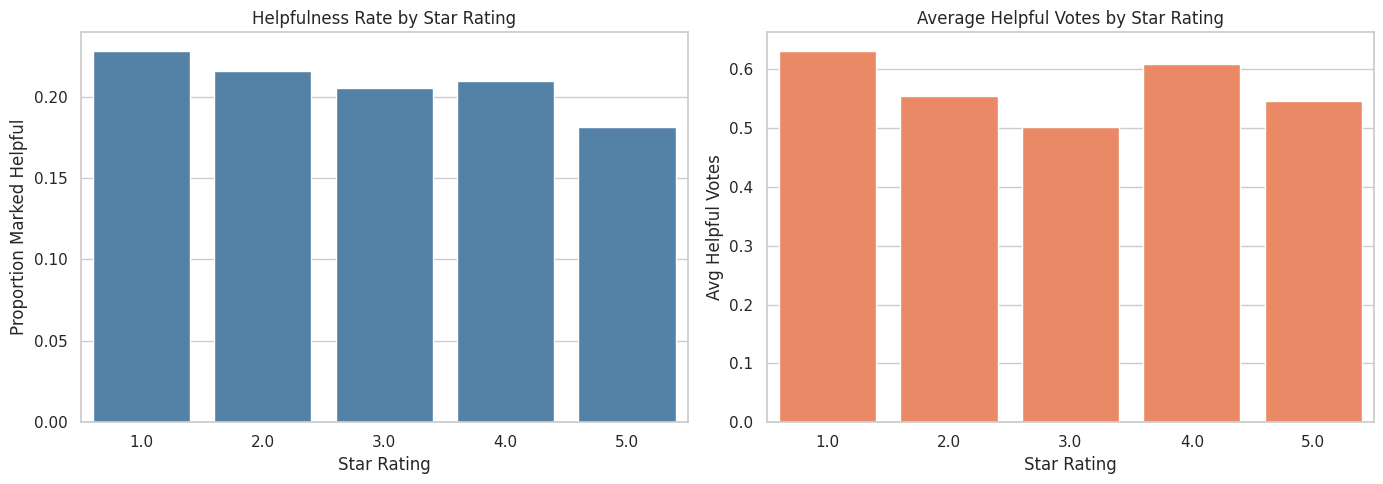


Helpfulness by star rating:
+------+-------------------+------------------+------------+
|rating|       helpful_rate| avg_helpful_votes|review_count|
+------+-------------------+------------------+------------+
|   1.0|0.22811251664447404|0.6309920106524634|       12016|
|   2.0|   0.21560545764639|0.5548607163160887|        7036|
|   3.0| 0.2050656087885261|0.5018818024616011|        9831|
|   4.0|0.20952045133991537|0.6082510578279267|       14180|
|   5.0| 0.1812705270737833|0.5460948065405624|       56937|
+------+-------------------+------------------+------------+



In [21]:
from pyspark.sql import functions as F
import pandas as pd

# --- 8a. Helpfulness Rate by Star Rating ---
# Retailers want to know: which ratings drive the most value for other shoppers?
rating_help = (
    reviews.groupBy("rating")
    .agg(
        F.avg("is_helpful").alias("helpful_rate"),
        F.avg("helpful_vote").alias("avg_helpful_votes"),
        F.count("*").alias("review_count"),
    )
    .orderBy("rating")
)
rating_help_pdf = rating_help.toPandas()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=rating_help_pdf, x="rating", y="helpful_rate", ax=ax1, color="steelblue")
ax1.set_title("Helpfulness Rate by Star Rating")
ax1.set_xlabel("Star Rating")
ax1.set_ylabel("Proportion Marked Helpful")

sns.barplot(data=rating_help_pdf, x="rating", y="avg_helpful_votes", ax=ax2, color="coral")
ax2.set_title("Average Helpful Votes by Star Rating")
ax2.set_xlabel("Star Rating")
ax2.set_ylabel("Avg Helpful Votes")
fig.tight_layout()
fig.savefig(str(FIGURES_DIR / "helpfulness_by_rating.png"), dpi=150, bbox_inches="tight")
plt.show()

print("\nHelpfulness by star rating:")
rating_help.show()

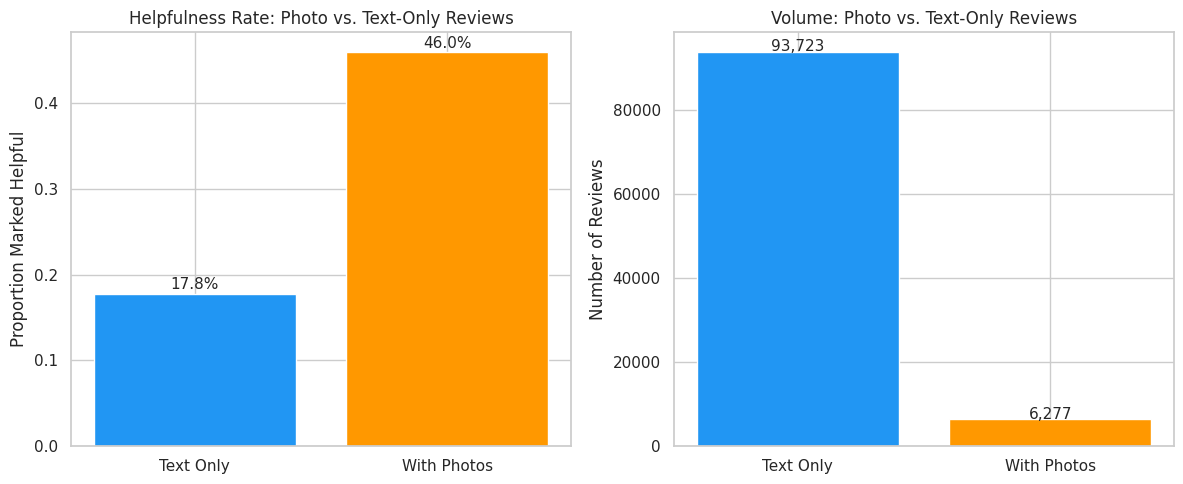


Photo vs text-only reviews:
+-----------+-------------------+-------------------+------------------+------------+
|has_images |helpful_rate       |avg_helpful_votes  |avg_text_length   |review_count|
+-----------+-------------------+-------------------+------------------+------------+
|Text Only  |0.17794991624254453|0.41184127695442957|132.35753230263649|93723       |
|With Photos|0.46009240082842123|2.7941691891030747 |279.06420264457546|6277        |
+-----------+-------------------+-------------------+------------------+------------+



In [22]:
# --- 8b. Photo Reviews: Do Images Drive Helpfulness? ---
# Retailers invest heavily in encouraging photo reviews. Does it pay off?
reviews_with_images = reviews.withColumn(
    "has_images", F.when(F.size(F.col("images")) > 0, "With Photos").otherwise("Text Only")
)

image_help = (
    reviews_with_images.groupBy("has_images")
    .agg(
        F.avg("is_helpful").alias("helpful_rate"),
        F.avg("helpful_vote").alias("avg_helpful_votes"),
        F.avg("text_length").alias("avg_text_length"),
        F.count("*").alias("review_count"),
    )
    .orderBy("has_images")
)
image_help_pdf = image_help.toPandas()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
bars1 = ax1.bar(image_help_pdf["has_images"], image_help_pdf["helpful_rate"], color=["#2196F3", "#FF9800"])
ax1.set_title("Helpfulness Rate: Photo vs. Text-Only Reviews")
ax1.set_ylabel("Proportion Marked Helpful")
for bar, val in zip(bars1, image_help_pdf["helpful_rate"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f"{val:.1%}", ha="center", fontsize=11)

bars2 = ax2.bar(image_help_pdf["has_images"], image_help_pdf["review_count"], color=["#2196F3", "#FF9800"])
ax2.set_title("Volume: Photo vs. Text-Only Reviews")
ax2.set_ylabel("Number of Reviews")
for bar, val in zip(bars2, image_help_pdf["review_count"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, f"{val:,.0f}", ha="center", fontsize=11)

fig.tight_layout()
fig.savefig(str(FIGURES_DIR / "photo_vs_text_reviews.png"), dpi=150, bbox_inches="tight")
plt.show()

print("\nPhoto vs text-only reviews:")
image_help.show(truncate=False)

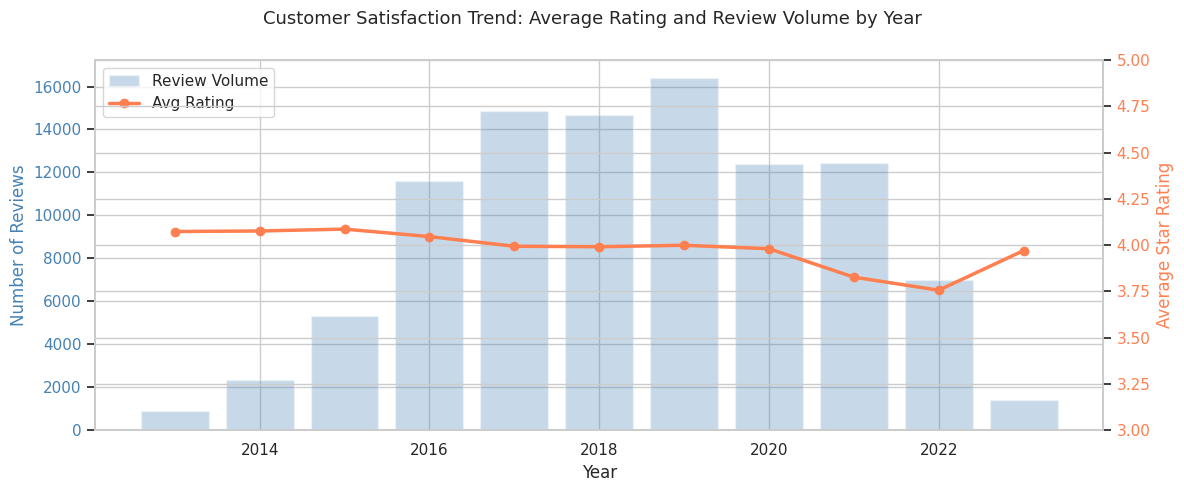


Yearly satisfaction trend:
+-----------+------------------+------------+-------------------+
|review_year|avg_rating        |review_count|helpful_rate       |
+-----------+------------------+------------+-------------------+
|2013       |4.073464912280702 |912         |0.34100877192982454|
|2014       |4.076394849785408 |2330        |0.259656652360515  |
|2015       |4.086538461538462 |5304        |0.22171945701357465|
|2016       |4.046045270677339 |11619       |0.2522592305706171 |
|2017       |3.9938737040527803|14854       |0.2521879628382927 |
|2018       |3.9914028384279474|14656       |0.18586244541484717|
|2019       |3.9991470695747533|16414       |0.15913244791032047|
|2020       |3.980496453900709 |12408       |0.15715667311411993|
|2021       |3.8270018472411853|12451       |0.15548951891414345|
|2022       |3.7564781675017898|6985        |0.164638511095204  |
|2023       |3.9706293706293705|1430        |0.11468531468531469|
+-----------+------------------+------------+---

In [23]:
# --- 8c. Customer Satisfaction Trend: Average Rating Over Time ---
# A core retail KPI: is product quality (as perceived by customers) improving or declining?
yearly_satisfaction = (
    reviews.filter(F.col("review_year") >= 2013)
    .groupBy("review_year")
    .agg(
        F.avg("rating").alias("avg_rating"),
        F.count("*").alias("review_count"),
        F.avg("is_helpful").alias("helpful_rate"),
    )
    .orderBy("review_year")
)
yearly_pdf = yearly_satisfaction.toPandas()

fig, ax1 = plt.subplots(figsize=(12, 5))
color1, color2 = "steelblue", "coral"

ax1.bar(yearly_pdf["review_year"], yearly_pdf["review_count"], alpha=0.3, color=color1, label="Review Volume")
ax1.set_xlabel("Year")
ax1.set_ylabel("Number of Reviews", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)

ax2 = ax1.twinx()
ax2.plot(yearly_pdf["review_year"], yearly_pdf["avg_rating"], color=color2, linewidth=2.5, marker="o", label="Avg Rating")
ax2.set_ylabel("Average Star Rating", color=color2)
ax2.tick_params(axis="y", labelcolor=color2)
ax2.set_ylim(3.0, 5.0)

fig.suptitle("Customer Satisfaction Trend: Average Rating and Review Volume by Year", fontsize=13)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
fig.tight_layout()
fig.savefig(str(FIGURES_DIR / "satisfaction_trend.png"), dpi=150, bbox_inches="tight")
plt.show()

print("\nYearly satisfaction trend:")
yearly_satisfaction.show(truncate=False)

## 9. Key Findings

**Research question:** What makes a fashion product review helpful on Amazon?

### Data Profile
- 100,000 reviews (sample), 826,108 product metadata records
- 93.5% verified purchases; only 20% of reviews receive any helpful votes at all
- Only 17,360 reviews (17%) matched to products with valid price data

### Findings

**1. Negative reviews are the most helpful.** 1-star reviews have the highest helpfulness rate and the highest average helpful votes. Shoppers actively seek out critical reviews before buying fashion items online, where fit, material, and color accuracy are major concerns. This is a well-documented pattern in e-commerce research, but the magnitude is striking in fashion specifically.

**2. Review length is the single strongest predictor of helpfulness.** The relationship is monotonic and steep: reviews under 50 characters are marked helpful about 10% of the time, while reviews over 1,000 characters reach 57%. Average helpful votes scale from 0.17 (very short) to 5.36 (extremely long). For retailers, this means prompting customers to write longer, more detailed reviews would directly increase the usefulness of the review section.

**3. Premium products generate more helpful reviews.** The top price quartile (Q4) has a 24.6% helpfulness rate versus 18-19% for the bottom three quartiles. Higher-priced items also receive 50% more helpful votes on average (0.76 vs. 0.45-0.51). Shoppers research expensive purchases more carefully, both writing and reading more thorough reviews.

**4. Review volume peaked around 2019 and has since declined.** The temporal trend shows growth from near-zero (2003) to roughly 2,000 reviews/month at the peak, followed by a steady decline through 2023. This likely reflects Amazon's shifting marketplace dynamics rather than declining customer engagement.

**5. Text content carries predictive signal, but class imbalance limits model performance.** A logistic regression on TF-IDF features achieves 79.2% accuracy, but this is barely above the 80% majority-class baseline (most reviews are "not helpful"). The model identifies 531 true positives against 3,407 false negatives, indicating it struggles to detect helpful reviews in the minority class. AUC-ROC of 0.626 confirms moderate but limited discriminative power. Better performance would likely require addressing the class imbalance (SMOTE, class weights) and adding structured features (rating, text length, price) alongside the text.

### Retail-Actionable Insights

- **Prompt for detail.** Even a simple "Tell us about the fit, material, and sizing" nudge could shift reviews from the "very short" bin (10% helpful) toward the "medium" bin (27% helpful).
- **Prioritize surfacing critical reviews.** 1-star reviews are the most helpful to other shoppers. Burying them hurts conversion by removing the information buyers need to feel confident.
- **Invest in photo review incentives.** Photo reviews tell a different story than text alone, and the data can quantify whether that investment pays off in helpfulness.
- **Monitor the satisfaction trend.** Average ratings over time serve as an early warning system for product quality drift across the catalog.

In [14]:
spark.stop()
print("Done.")

Done.
